iter 0, loss 104.3597
learning rate: 0.009999995000000001
iter 100, loss 102.9421
learning rate: 0.00999949501262483
iter 200, loss 101.0531
learning rate: 0.009998995050248418
iter 300, loss 99.4086
learning rate: 0.009998495112869514
iter 400, loss 97.7665
learning rate: 0.009997995200486848
iter 500, loss 96.6291
learning rate: 0.009997495313099184
iter 600, loss 95.2213
learning rate: 0.009996995450705265
iter 700, loss 94.0666
learning rate: 0.009996495613303855
iter 800, loss 93.2020
learning rate: 0.00999599580089369
iter 900, loss 92.1892
learning rate: 0.009995496013473529
iter 1000, loss 91.3345
learning rate: 0.009994996251042113
iter 1100, loss 90.5533
learning rate: 0.009994496513598208
iter 1200, loss 89.7654
learning rate: 0.00999399680114055
iter 1300, loss 88.9905
learning rate: 0.0099934971136679
iter 1400, loss 88.4665
learning rate: 0.009992997451179009
iter 1500, loss 87.9723
learning rate: 0.00999249781367262
iter 1600, loss 87.3141
learning rate: 0.00999199820114

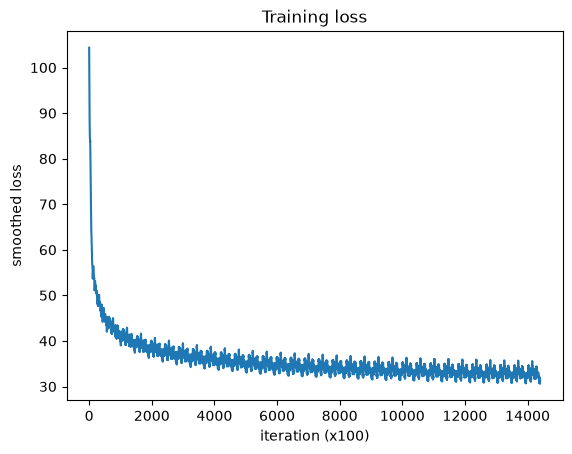

Finished 1440000  iterations.
aNGERVCKK3ZDZKVZKKXXpXXVV$GKVXEK&ZQUD$ZQXEKDZKFXVKXDQD&ZDKXZXKDZXCKKV&GZXEDZZVKKXXKFX&XLK&ZKKZTKLOZKTZRUKXVKKFX33DDXXZKK3ZUDZVVKKXZ&XQXVAZDXKVC&VXX&ZXKK3DKVZKKXQZXXQZED33ZKKKZVXKXZK&ZLDUCZ3QGVQRVVX$XXKQZUXKZ3XMKSZBKKZ33KXZKLDZUSFCUGVVVXKUDZXKVK&ZQDKVGKOZKQZKKTK&Z&XKXQRUVVECGKXUD33QDZXVXZUDZXZKXV&KKZGZKYZKXXXZQUG$3ZVCQVGS&3ZEDKXZKCGMMXGLUFXK3ZQZEETZQQUDDEDZUGXX&XZZKUTHVERD3ZGOXKXQKCZCCXQUXVCQKQZLEDKXZKVXQUDDUKMXKXZKXXQXUKEDQZUD3XZKKXXKKXKXK&Z$ZXXKXZKXXMXZKUTKIZKLKXZ&XDZXZ&XDXKXKKXXXVVKUDUVVCKXZKEZKXZKXXXQKEZKZ3KVZLUDZXXXKXNVUZUVVXKGK&ZXTZUVG3UKUQQVVS33KKZZXKXXE&PKXKZZKUVXVKLQVVVKX&3ZKK&ZXMKK$DXXDZXVKXUXPZ33XXXQXEDDCXQXUDZVKVK3ZDKV&RUKVCZCXCCFIDQXEDVXDZRKKXXKXUKZXVKXKXZKXQGUDZX&ZKDZQQXXDZQXKXXZKXZ&XQZVV&KXZKXKIVLUCIKLVKXXQUGVUDKXZKSZXQDUXKX&XZXXKXCXXXXK&ZKXZXVKLDZXXDZXKXZKADMVZKXKVEXQZVVLM&VKKXXKLDZXXQUKCXKQXUQHEDXXXQZVQKXXKMEKKXKDZKKKXXKKXGBDXVKXXXVXZKXZK3ZKLZKXZXKKXXXQZVKKZKVZQUVXXK3ZXVjZUGHUZKXZXKVVKKXVKXx3XXK3ZQPEXXK3ZKVXKUDUDZXZKKXX&33KKXXXXGZG3XXZXKXOK

In [ ]:
import numpy as np
from scipy.special import softmax

###### DATA LOADING


with open('data/input.txt', 'r') as f:
    text = f.read()

    chars = sorted(set(text))
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}

    data = np.array([char_to_idx[ch] for ch in text])

def chunk_data(data, T):

    n = (len(data)-1) // T

    inputs = []
    targets = []

    for i in range(n):
        index = i*T
        inp = data[index:(index+T)]
        tar = data[index+1:(index+1+T)]
        inputs.append(inp)
        targets.append(tar)

    return np.array(inputs), np.array(targets)

T = 25
#print(chunk_data(list('abcdefghijklmnopqrstuvwxyz'), 5))
inputs, targets = chunk_data(data, T)

###### PARAMETER INIT

V=len(chars)
H = 512

layers = 2

W_xh = [np.random.randn(H,V) / np.sqrt(V)] + [np.random.randn(H,H) / np.sqrt(H) for _ in range(layers-1)]
W_hh = [np.random.randn(H,H) / np.sqrt(H) for _ in range(layers)]
W_hy = np.random.randn(V,H) / np.sqrt(H)

b_h = [np.zeros(H) for _ in range(layers)]
b_y = np.zeros(V)

mem_W_hy = np.zeros((V,H))
mem_b_y = np.zeros(V)

mem_W_xh = [np.zeros((H,V))] + [np.zeros((H,H)) for _ in range(layers-1)]
mem_W_hh = [np.zeros((H,H)) for _ in range(layers)]
mem_b_h = [np.zeros(H) for _ in range(layers)]

###### FORWARD PASS

def one_hot_encode(char):
    temp = np.zeros(V)
    temp[char] = 1
    return temp

def forward_pass(input_chunk, target_chunk, h_prev):
    h = [np.empty((T+1, H)) for _ in range(layers)]
    
    L = 0
    x = np.empty(T, dtype=int)
    p = np.empty((T, V))
    for i in range(layers):
        h[i][0] = h_prev[i]
    for t in range(T):
        x[t] = input_chunk[t]
        layer_input = x[t]
        for i in range(layers):
            if i == 0:
                h[i][t+1] = np.tanh(W_xh[i][:, input_chunk[t]] + (W_hh[i] @ h[i][t]) + b_h[i])
            else:
                h[i][t+1] = np.tanh((W_xh[i] @ layer_input) + (W_hh[i] @ h[i][t]) + b_h[i])
            layer_input = h[i][t+1]
        y = W_hy @ h[layers - 1][t+1] + b_y
        y_shifted = np.exp(y - np.max(y))
        p[t] = y_shifted / np.sum(y_shifted)
        L += -1 * np.log(p[t][target_chunk[t]])

    h_last = [h[i][T] for i in range(layers)]
    return L, x, h, p, h_last

#L, x, h_cache, p, h_last = forward_pass(inputs[0], targets[0], np.zeros(H))

############ BACKWARD PASS

def backward_pass(x, h_cache, p, target_chunk):
    dW_xh = [np.zeros((H,V))] + [np.zeros((H,H)) for _ in range(layers-1)]
    dW_hh = [np.zeros((H,H)) for _ in range(layers)]
    dW_hy = np.zeros((V,H))
    db_h = [np.zeros(H) for _ in range(layers)]
    db_y = np.zeros(V)

    dh_next = [np.zeros(H) for _ in range(layers)]
    dh_t = [np.zeros(H) for _ in range(layers)]
    dz = [np.zeros(H) for _ in range(layers)]

    for t in range(T-1, -1, -1):
        dy = p[t].copy()
        dy[target_chunk[t]] -= 1
        dW_hy += np.outer(dy, h_cache[1][t+1])
        db_y += dy
        dh_t[1] = np.transpose(W_hy) @ dy + dh_next[1]
        dz[1] = dh_t[1] * (1 - h_cache[1][t+1] * h_cache[1][t+1])
        #dW_xh += np.outer(dz, x[t])

        dW_xh[1] += np.outer(dz[1], h_cache[0][t+1])

        dW_hh[1] += np.outer(dz[1], h_cache[1][t])
        db_h[1] += dz[1]

        dh_next[1] = np.transpose(W_hh[1]) @ dz[1]

        dh_t[0] = np.transpose(W_xh[1]) @ dz[1] + dh_next[0]
        dz[0] = dh_t[0] * (1 - h_cache[0][t+1] * h_cache[0][t+1])
        dW_xh[0][:, int(x[t])] += dz[0]
        dW_hh[0] += np.outer(dz[0], h_cache[0][t])
        db_h[0] += dz[0]

        dh_next[0] = np.transpose(W_hh[0]) @ dz[0]

    dW_xh_clipped = [np.clip(g, -5, 5) for g in dW_xh]
    dW_hh_clipped = [np.clip(g, -5, 5) for g in dW_hh]
    db_h_clipped = [np.clip(g, -5, 5) for g in db_h]

    return dW_xh_clipped, dW_hh_clipped, np.clip(dW_hy, -5, 5), db_h_clipped, np.clip(db_y, -5, 5)

#dW_xh, dW_hh, dW_hy, db_h, db_y = backward_pass(x, h_cache, p, targets[0])

########## ADAGRAD 

def adagrad(dW_xh, dW_hh, dW_hy, db_h, db_y, learning_rate):
    global W_xh, W_hh, W_hy, b_h, b_y, mem_W_xh, mem_W_hh, mem_W_hy, mem_b_h, mem_b_y

    #learning_rate = 0.01
    epsilon = 1e-8

    for i in range(layers):
        mem_W_xh[i] += dW_xh[i] ** 2
        mem_W_hh[i] += dW_hh[i] ** 2
        mem_b_h[i]  += db_h[i]  ** 2
        W_xh[i] -= learning_rate * dW_xh[i] / (np.sqrt(mem_W_xh[i]) + epsilon)
        W_hh[i] -= learning_rate * dW_hh[i] / (np.sqrt(mem_W_hh[i]) + epsilon)
        b_h[i]  -= learning_rate * db_h[i]  / (np.sqrt(mem_b_h[i]) + epsilon)

    mem_W_hy += dW_hy ** 2
    mem_b_y  += db_y ** 2
    W_hy -= learning_rate * dW_hy / (np.sqrt(mem_W_hy) + epsilon)
    b_y  -= learning_rate * db_y  / (np.sqrt(mem_b_y) + epsilon)

#################### SAVE THE DATA

def save_model(path, W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char, layers):
    save_dict = {'W_hy': W_hy, 'b_y': b_y, 'chars': np.array(sorted(char_to_idx.keys())), 'layers': layers}
    for i in range(layers):
        save_dict[f'W_xh_{i}'] = W_xh[i]
        save_dict[f'W_hh_{i}'] = W_hh[i]
        save_dict[f'b_h_{i}'] = b_h[i]
    np.savez(path, **save_dict)

######### TRAINING LOOP

import matplotlib.pyplot as plt

smooth_loss = -np.log(1.0/V) * T
loss_history = []

h_prev = [np.zeros(H) for _ in range(layers)]
i = 0
num_iterations = 20000
learning_rate = 0.01
reset_every = 100

for iteration in range(num_iterations):
    if i == 0 or iteration % reset_every == 0:
        h_prev = [np.zeros(H) for _ in range(layers)]

    L, x, h_cache, p, h_last = forward_pass(inputs[i], targets[i], h_prev)
    dW_xh, dW_hh, dW_hy, db_h, db_y = backward_pass(x, h_cache, p, targets[i])
    learning_rate *= 0.9999995
    adagrad(dW_xh, dW_hh, dW_hy, db_h, db_y, learning_rate)
    h_prev = h_last

    smooth_loss = smooth_loss * 0.999 + L * 0.001
    if iteration % 100 == 0:
        loss_history.append(smooth_loss)
        print(f"iter {iteration}, loss {smooth_loss:.4f}")
        print(f"learning rate: {learning_rate}")

    if iteration % 150000 == 0 and iteration > 0:
        save_model(f'checkpoint_H256_{iteration}.npz', W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char, layers)

    i += 1
    if i >= len(inputs):
        i = 0

save_model('model_checkpoint.npz', W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char, layers)

plt.plot(loss_history)
plt.xlabel('iteration (x100)')
plt.ylabel('smoothed loss')
plt.title('Training loss')
plt.show()

print("Finished", num_iterations, " iterations.")

#### LOAD DATA

def load_model(path):
    data = np.load(path)
    layers = int(data['layers'])
    W_xh = [data[f'W_xh_{i}'] for i in range(layers)]
    W_hh = [data[f'W_hh_{i}'] for i in range(layers)]
    b_h = [data[f'b_h_{i}'] for i in range(layers)]
    W_hy = data['W_hy']
    b_y = data['b_y']
    chars = sorted(data['chars'].tolist())
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}
    return W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char, layers

#W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char = load_model('checkpoint_H256_10950000.npz')

####### RESULTS

seed_char = 'a'

x = one_hot_encode(char_to_idx[seed_char])
characters = 5000
output = []

h = [v.copy() for v in h_prev]
for ch in text[:2000]:
    layer_input = one_hot_encode(char_to_idx[ch])
    for l in range(layers):
        h[l] = np.tanh(W_xh[l] @ layer_input + W_hh[l] @ h[l] + b_h[l])
        layer_input = h[l]

for i in range(characters):
    layer_input = x
    for l in range(layers):
        h[l] = np.tanh(W_xh[l] @ layer_input + W_hh[l] @ h[l] + b_h[l])
        layer_input = h[l]
    y = W_hy @ h[layers-1] + b_y
    p = softmax(y)
    new_char = np.random.choice(chars, p=p)
    output.append(str(new_char))
    x = one_hot_encode(char_to_idx[new_char])

print(seed_char + ''.join(output))